# 1. MathDial exploratory data analysis

This notebook explores the train and test MathDial datasets in this repository. Solution rows are kept separate from real student turns so deliberately incorrect solutions do not distort turn-level correctness.

## 1.1 Annotation key

The five misconception families use `P` = present, `A` = absent, and `N` = not evidenced. An `N` is not evidence that a misconception is absent or resolved.

In [13]:
from ast import literal_eval
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from scripts.load_data import (
    apply_final_turn_override,
    load_csv,
    load_paper_filtered_data,
    remove_dialogues_below_typicality_threshold,
    remove_dialogues_with_failed_correctness_and_kc_annotation,
)

DATA_DIR = Path("data")
SPLITS = ["train", "test"]
FAMILIES = ["comprehension", "relevance", "principles", "wrong_operation", "steps"]
FAMILY_NAMES = [name.replace("_", " ").title() for name in FAMILIES]
STATES = ["P", "A", "N"]
STATE_COLORS = {"P": "#C44E52", "A": "#55A868", "N": "#B8BDC7"}
SPLIT_COLORS = {"train": "#4C72B0", "test": "#DD8452"}
plt.style.use("seaborn-v0_8-whitegrid")

raw = {split: load_csv(DATA_DIR / f"mathdial_{split}.csv") for split in SPLITS}
filtered = {
    split: load_paper_filtered_data(DATA_DIR / f"mathdial_{split}.csv")
    for split in SPLITS
}

raw_summary = pd.DataFrame({
    split: {
        "dialogues": frame["dialogue_id"].nunique(),
        "rows": len(frame),
        "solution_rows": frame["turn"].eq("solution").sum(),
        "real_turn_rows": frame["turn"].ne("solution").sum(),
    }
    for split, frame in raw.items()
}).T

for frame in raw.values():
    assert frame[FAMILIES].isin(STATES).all().all()
    assert frame.groupby("dialogue_id")["turn"].apply(lambda values: values.eq("solution").sum()).eq(1).all()

display(raw_summary)

,dialogues,rows,solution_rows,real_turn_rows
train,2253,15609,2253,13356
test,595,3902,595,3307


# 2. Paper-filtered MathDial data

The paper keeps dialogues with typicality scores of at least 1, removes failed annotations and dialogues with fewer than two usable real turns, applies the human final-turn correctness override, and expands each retained turn to one row per knowledge component (KC).

In [14]:
paper = {}
audit_rows = []

for split in SPLITS:
    data = filtered[split]
    dialogues = data[data["turn"].eq("solution")].copy()
    turns = data[data["turn"].ne("solution")].copy()
    turns["kcs_list"] = turns["kcs"].map(literal_eval)
    turns["correct_value"] = turns["correct"].astype("string").str.lower().eq("true")
    turns["turn_number"] = pd.to_numeric(turns["turn"].str.extract(r"(\d+)")[0])
    turns = turns.sort_values(["dialogue_id", "turn_number"])
    turns["real_rank"] = turns.groupby("dialogue_id").cumcount() + 1
    turns["n_real_tagged"] = turns.groupby("dialogue_id")["turn"].transform("size")
    turns["n_kcs"] = turns["kcs_list"].map(len)

    long = (
        turns[["dialogue_id", "turn_number", "correct_value", "kcs_list"]]
        .explode("kcs_list")
        .rename(columns={"turn_number": "turn", "correct_value": "correct", "kcs_list": "kc"})
    )
    long["correct"] = long["correct"].astype(int)
    paper[split] = {"dialogues": dialogues, "turns": turns, "long": long}

    after_typical = remove_dialogues_below_typicality_threshold(raw[split])
    after_failed = remove_dialogues_with_failed_correctness_and_kc_annotation(after_typical)
    after_override = apply_final_turn_override(after_failed)
    last_turns = after_failed[after_failed["turn"].ne("solution")].groupby("dialogue_id", sort=False).tail(1)
    last_kcs = last_turns["kcs"].fillna("").astype(str).str.strip()
    eligible = last_turns["correct"].notna() & ~last_kcs.isin(["", "[]"])
    changed = (
        last_turns.loc[eligible, "correct"].fillna("").astype(str)
        != after_override.loc[last_turns.index[eligible], "correct"].fillna("").astype(str)
    ).sum()

    audit_rows.append({
        "split": split,
        "raw_dialogues": raw[split]["dialogue_id"].nunique(),
        "after_typical_cutoff_1": after_typical["dialogue_id"].nunique(),
        "failed_dialogues_removed": after_typical["dialogue_id"].nunique() - after_failed["dialogue_id"].nunique(),
        "fewer_than_2_tagged_removed": after_failed["dialogue_id"].nunique() - len(dialogues),
        "dialogues_kept": len(dialogues),
        "tagged_true_turns": len(turns),
        "kc_pseudo_observations": len(long),
        "distinct_kcs": long["kc"].nunique(),
        "test_style_scored_turns": len(turns) - len(dialogues),
        "eligible_final_overrides": int(eligible.sum()),
        "changed_or_removed_by_override": int(changed),
    })

audit = pd.DataFrame(audit_rows).set_index("split")
display(audit)

,raw_dialogues,after_typical_cutoff_1,failed_dialogues_removed,fewer_than_2_tagged_removed,dialogues_kept,tagged_true_turns,kc_pseudo_observations,distinct_kcs,test_style_scored_turns,eligible_final_overrides,changed_or_removed_by_override
split,,,,,,,,,,,
train,2253,2253,18,185,2050,10448,23953,138,8398,1887,413
test,595,595,7,73,515,2500,5788,94,1985,501,118


In [15]:
expected = {
    "train": {"dialogues_kept": 2050, "tagged_true_turns": 10448, "kc_pseudo_observations": 23953, "distinct_kcs": 138},
    "test": {"dialogues_kept": 515, "tagged_true_turns": 2500, "kc_pseudo_observations": 5788, "distinct_kcs": 94},
}
for split, values in expected.items():
    for column, value in values.items():
        assert audit.loc[split, column] == value, f"Unexpected {split} {column}"

for split in SPLITS:
    assert paper[split]["turns"].groupby("dialogue_id").size().ge(2).all()
    assert paper[split]["long"].groupby(["dialogue_id", "turn"])["correct"].nunique().eq(1).all()

print("Paper-filter replication checks passed.")

Paper-filter replication checks passed.


## 2.1 Dataset shape and correctness

Correctness is counted once per real turn. The pseudo-observation rate shows the weighting change caused by expanding multi-KC turns.

,dialogues,true_turns,pseudo_observations,fraction_correct,majority_accuracy,mean_turns_per_dialogue,median_turns_per_dialogue,min_turns,max_turns,mean_kcs_per_turn,pseudo_observation_correctness
split,,,,,,,,,,,
train,2050,10448,23953,0.498,0.502,5.097,5.0,2,20,2.293,0.497
test,515,2500,5788,0.460,0.540,4.854,4.0,2,13,2.315,0.460


Paper-scored test turns: 1,985; correctness: 0.474


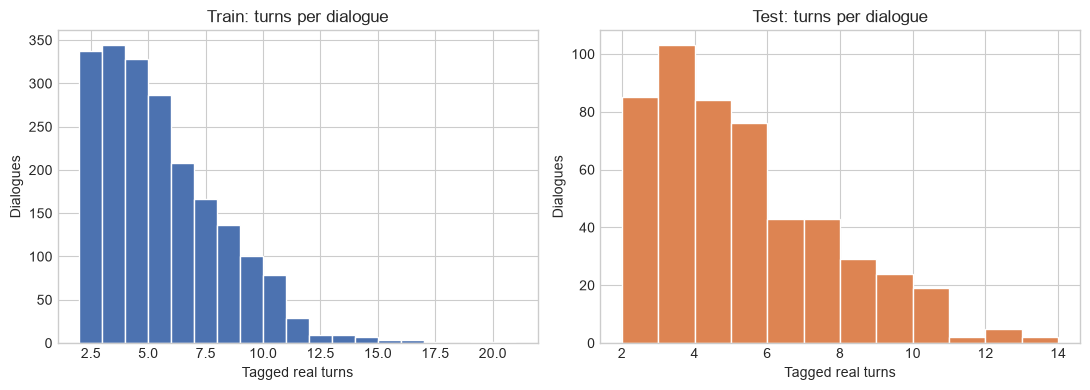

In [16]:
shape_rows = []
for split in SPLITS:
    turns = paper[split]["turns"]
    long = paper[split]["long"]
    lengths = turns.groupby("dialogue_id").size()
    correct_rate = turns["correct_value"].mean()
    shape_rows.append({
        "split": split, "dialogues": lengths.size, "true_turns": len(turns),
        "pseudo_observations": len(long), "fraction_correct": correct_rate,
        "majority_accuracy": max(correct_rate, 1 - correct_rate),
        "mean_turns_per_dialogue": lengths.mean(), "median_turns_per_dialogue": lengths.median(),
        "min_turns": lengths.min(), "max_turns": lengths.max(),
        "mean_kcs_per_turn": len(long) / len(turns),
        "pseudo_observation_correctness": long["correct"].mean(),
    })

display(pd.DataFrame(shape_rows).set_index("split").round(3))
test_scored = paper["test"]["turns"].query("real_rank > 1")
print(f"Paper-scored test turns: {len(test_scored):,}; correctness: {test_scored['correct_value'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split in zip(axes, SPLITS):
    lengths = paper[split]["turns"].groupby("dialogue_id").size()
    ax.hist(lengths, bins=range(int(lengths.min()), int(lengths.max()) + 2), color=SPLIT_COLORS[split], edgecolor="white")
    ax.set(title=f"{split.title()}: turns per dialogue", xlabel="Tagged real turns", ylabel="Dialogues")
plt.tight_layout()
plt.show()

## 2.2 Knowledge components

These diagnostics cover KC frequency, rare and degenerate KCs, KCs per turn, and train/test coverage. KC coverage is calculated directly from the values observed in the CSV files.

,value
KCs observed across both splits,144
observed train KCs,138
observed test KCs,94
train KCs occurring once,12
train KCs occurring at most twice,21
train KCs occurring at most five times,45
degenerate train KCs,20
degenerate pseudo-observations,37
test-only KCs,6
test turns affected by test-only KCs,11


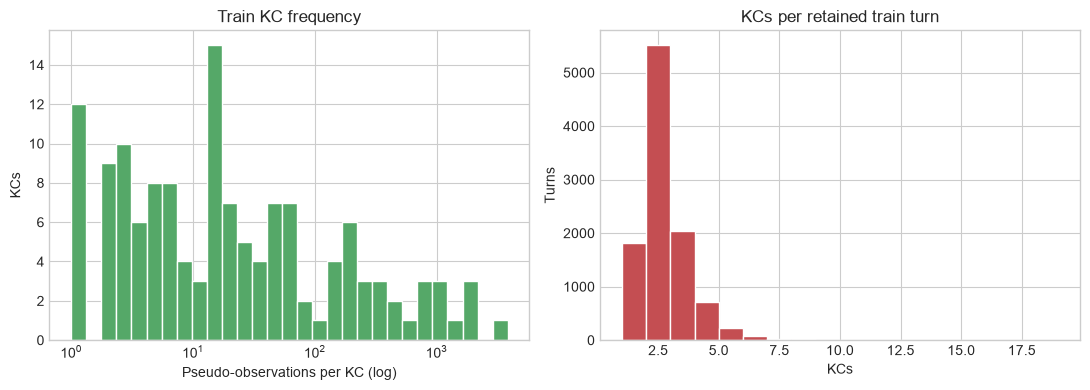

In [17]:
train_long = paper["train"]["long"]
test_long = paper["test"]["long"]
train_kcs = train_long.groupby("kc")["correct"].agg(n="count", n_correct="sum")
test_kcs = test_long.groupby("kc")["correct"].agg(n="count", n_correct="sum")
degenerate = train_kcs.query("n_correct == 0 or n_correct == n")
test_only = set(test_kcs.index) - set(train_kcs.index)
affected_turns = test_long[test_long["kc"].isin(test_only)][["dialogue_id", "turn"]].drop_duplicates()

kc_summary = pd.Series({
    "KCs observed across both splits": len(set(train_kcs.index) | set(test_kcs.index)),
    "observed train KCs": len(train_kcs), "observed test KCs": len(test_kcs),
    "train KCs occurring once": train_kcs["n"].eq(1).sum(),
    "train KCs occurring at most twice": train_kcs["n"].le(2).sum(),
    "train KCs occurring at most five times": train_kcs["n"].le(5).sum(),
    "degenerate train KCs": len(degenerate),
    "degenerate pseudo-observations": degenerate["n"].sum(),
    "test-only KCs": len(test_only),
    "test turns affected by test-only KCs": len(affected_turns),
}, name="value")
display(kc_summary.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_kcs["n"], bins=np.logspace(0, np.log10(train_kcs["n"].max()), 30), color="#55A868", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set(title="Train KC frequency", xlabel="Pseudo-observations per KC (log)", ylabel="KCs")
max_kcs = int(paper["train"]["turns"]["n_kcs"].max())
axes[1].hist(paper["train"]["turns"]["n_kcs"], bins=range(1, max_kcs + 2), color="#C44E52", edgecolor="white")
axes[1].set(title="KCs per retained train turn", xlabel="KCs", ylabel="Turns")
plt.tight_layout()
plt.show()

## 2.3 Native MathDial misconception structure

MathDial supplies a broad student-profile family and a free-text teacher description. These are descriptive context, not extra filters.

,train,test
family,,
comprehension,382,89
principles,352,97
relevance,293,86
wrong-operation,352,93
steps,333,72
problem-type,338,78


,train,test
family,,
comprehension,0.502,0.474
principles,0.517,0.44
relevance,0.486,0.469
wrong-operation,0.479,0.496
steps,0.507,0.479
problem-type,0.5,0.402


,dialogues,distinct_described_confusions,fraction_unique
train,2050,2040,0.995
test,515,513,0.996


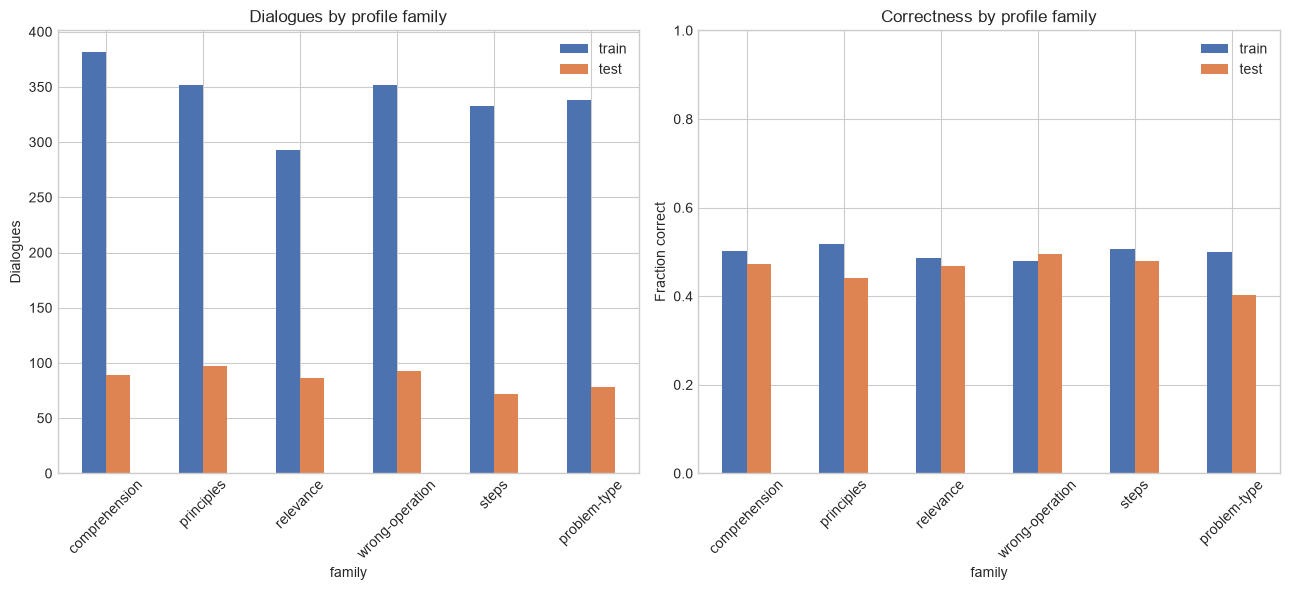

In [18]:
family_order = ["comprehension", "principles", "relevance", "wrong-operation", "steps", "problem-type"]
family_counts = pd.concat({
    split: paper[split]["dialogues"]["family"].value_counts().reindex(family_order) for split in SPLITS
}, axis=1).fillna(0).astype(int)
family_correctness = pd.concat({
    split: paper[split]["turns"].groupby("family")["correct_value"].mean().reindex(family_order) for split in SPLITS
}, axis=1)
confusion_summary = pd.DataFrame({
    split: {
        "dialogues": len(paper[split]["dialogues"]),
        "distinct_described_confusions": paper[split]["dialogues"]["teacher_described_confusion"].nunique(),
    } for split in SPLITS
}).T
confusion_summary["fraction_unique"] = confusion_summary["distinct_described_confusions"] / confusion_summary["dialogues"]

display(family_counts)
display(family_correctness.round(3))
display(confusion_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
family_counts.plot.bar(ax=axes[0], color=[SPLIT_COLORS[s] for s in SPLITS], title="Dialogues by profile family")
family_correctness.plot.bar(ax=axes[1], color=[SPLIT_COLORS[s] for s in SPLITS], title="Correctness by profile family")
axes[0].set_ylabel("Dialogues")
axes[1].set(ylabel="Fraction correct", ylim=(0, 1))
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 2.4 Filtering sensitivity

This measures the impact of the final-turn override, stricter typicality, and stricter minimum dialogue lengths.

In [19]:
override_summary = audit[["eligible_final_overrides", "changed_or_removed_by_override"]].copy()
override_summary["fraction_changed_or_removed"] = override_summary["changed_or_removed_by_override"] / override_summary["eligible_final_overrides"]

typicality = {}
length_rows = []
for split in SPLITS:
    typicality[split] = {
        f"cutoff_{cutoff}": remove_dialogues_below_typicality_threshold(
            raw[split], cutoff
        )["dialogue_id"].nunique()
        for cutoff in [1, 2]
    }
    lengths = paper[split]["turns"].groupby("dialogue_id").size()
    for minimum in range(2, 7):
        length_rows.append({
            "split": split, "minimum_tagged_turns": minimum,
            "dialogues_kept": lengths.ge(minimum).sum(),
            "fraction_of_paper_population": lengths.ge(minimum).mean(),
        })

display(override_summary.round(3))
display(pd.DataFrame(typicality).T)
display(pd.DataFrame(length_rows).pivot(index="minimum_tagged_turns", columns="split").round(3))

,eligible_final_overrides,changed_or_removed_by_override,fraction_changed_or_removed
split,,,
train,1887,413,0.219
test,501,118,0.236


,cutoff_1,cutoff_2
train,2253,2021
test,595,541


dialogues_kept       fraction_of_paper_population       
split                          test train                         test  train
minimum_tagged_turns                                                         
2                               515  2050                        1.000  1.000
3                               430  1713                        0.835  0.836
4                               327  1369                        0.635  0.668
5                               243  1041                        0.472  0.508
6                               167   754                        0.324  0.368

# 3. P11 annotation analysis

For comparability, this uses only the dialogues retained above. Each dialogue contributes its solution row and its usable tagged real turns.

In [20]:
model_parts = []
integrity_rows = []

for split in SPLITS:
    frame = raw[split]
    solutions = paper[split]["dialogues"].copy()
    solutions = solutions.assign(split=split, role="solution", real_rank=0, correct_value=False)
    turns = paper[split]["turns"].copy().assign(split=split, role="tagged real turn")
    columns = ["split", "dialogue_id", "role", "real_rank", "correct_value", "family", *FAMILIES]
    model_parts.extend([solutions[columns], turns[columns]])

    present = frame[FAMILIES].eq("P")
    sources = pd.DataFrame({family: frame[f"{family}_src"].fillna("").str.strip().ne("") for family in FAMILIES})
    integrity_rows.append({
        "split": split, "rows": len(frame), "dialogues": frame["dialogue_id"].nunique(),
        "annotation_cells": frame[FAMILIES].size,
        "valid_P_A_N_cells": frame[FAMILIES].isin(STATES).sum().sum(),
        "P_cells": present.sum().sum(), "P_cells_with_source": (present & sources).sum().sum(),
        "solution_rows_with_dialogue_threads": frame.loc[frame["turn"].eq("solution"), "dialogue_threads"].fillna("").str.strip().ne("").sum(),
    })

model_units = pd.concat(model_parts, ignore_index=True)
integrity = pd.DataFrame(integrity_rows).set_index("split")
assert integrity["annotation_cells"].eq(integrity["valid_P_A_N_cells"]).all()
assert integrity["P_cells"].eq(integrity["P_cells_with_source"]).all()
assert integrity["solution_rows_with_dialogue_threads"].eq(integrity["dialogues"]).all()
display(integrity)
display(model_units.groupby(["split", "role"]).size().unstack(fill_value=0))

,rows,dialogues,annotation_cells,valid_P_A_N_cells,P_cells,P_cells_with_source,solution_rows_with_dialogue_threads
split,,,,,,,
train,15609,2253,78045,78045,9399,9399,2253
test,3902,595,19510,19510,2483,2483,595


role,solution,tagged real turn
split,,
test,515,2500
train,2050,10448


## 3.1 Annotation-state composition

The panels compare `P`, `A`, and `N` by split and unit role. A high `N` rate means the construct is often not evidenced.

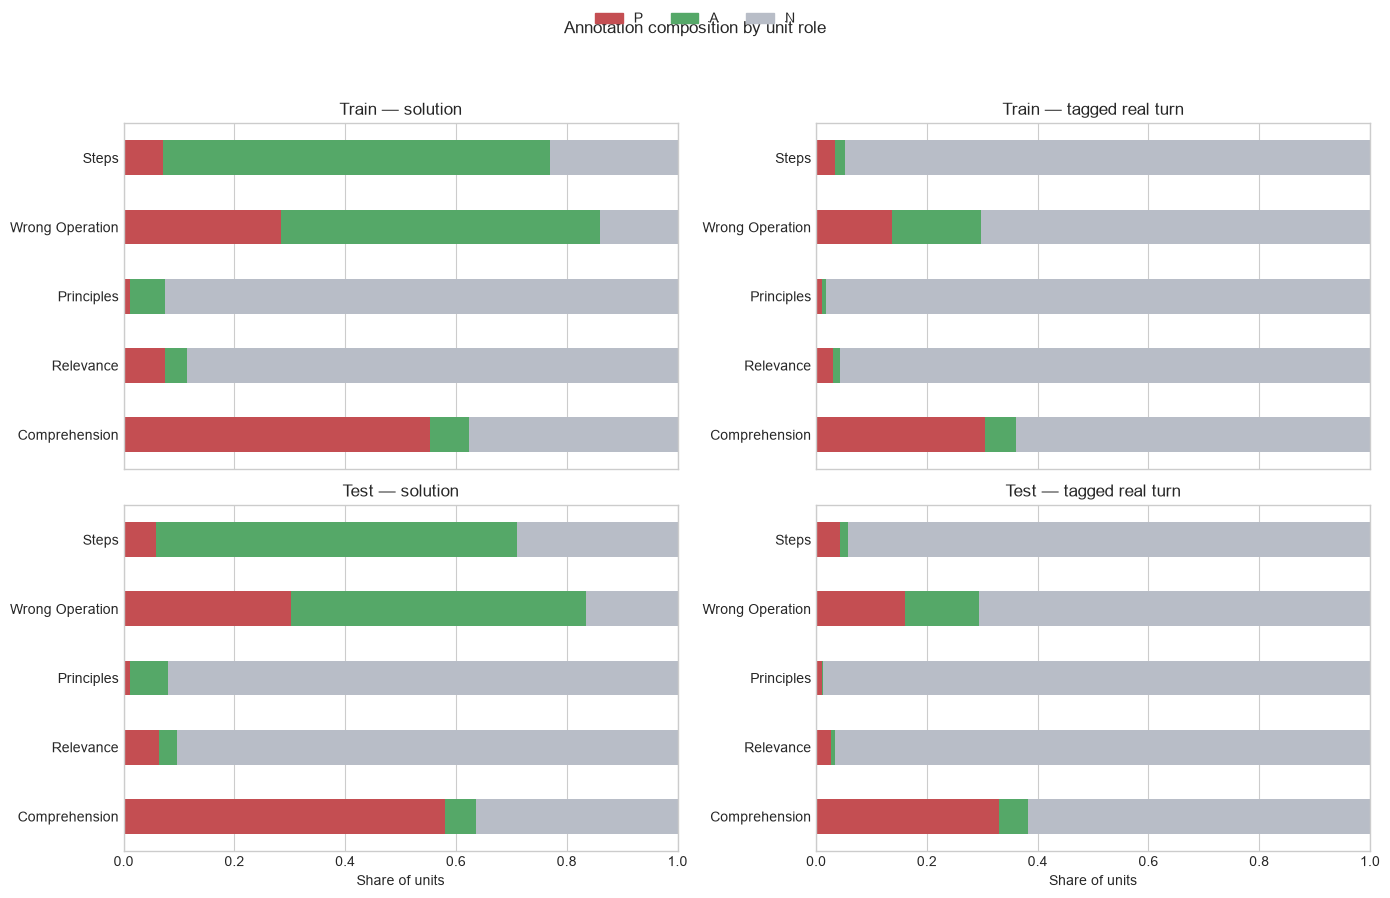

solution               tagged real turn              
                       P      A      N                P      A      N
comprehension      0.559  0.067  0.373            0.309  0.055  0.635
relevance          0.072  0.038  0.890            0.029  0.012  0.959
principles         0.011  0.065  0.924            0.010  0.007  0.983
wrong_operation    0.288  0.567  0.144            0.141  0.155  0.703
steps              0.069  0.688  0.242            0.036  0.017  0.947

In [21]:
def state_shares(frame):
    return pd.DataFrame({
        family: frame[family].value_counts(normalize=True).reindex(STATES, fill_value=0) for family in FAMILIES
    }).T


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
roles = ["solution", "tagged real turn"]
for ax, (split, role) in zip(axes.flat, [(split, role) for split in SPLITS for role in roles]):
    subset = model_units.query("split == @split and role == @role")
    state_shares(subset).plot.barh(stacked=True, ax=ax, color=STATE_COLORS, legend=False)
    ax.set(title=f"{split.title()} — {role}", xlabel="Share of units", ylabel="", xlim=(0, 1))
    ax.set_yticklabels(FAMILY_NAMES)

handles = [plt.Rectangle((0, 0), 1, 1, color=STATE_COLORS[state]) for state in STATES]
fig.legend(handles, STATES, loc="upper center", ncol=3)
fig.suptitle("Annotation composition by unit role", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

combined_shares = pd.concat({role: state_shares(model_units[model_units["role"].eq(role)]) for role in roles}, axis=1)
display(combined_shares.round(3))

## 3.2 Initial misconception burden

This counts how many misconception families are simultaneously present in each incorrect solution.

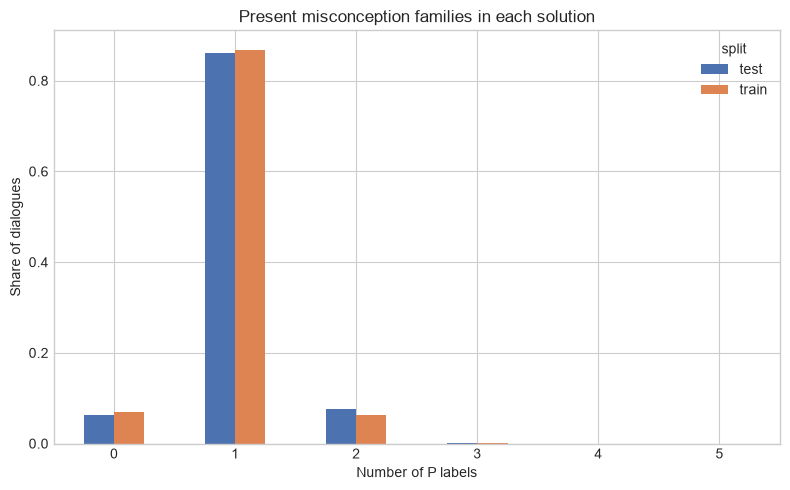

,fraction
n_present,
0,0.068
1,0.866
2,0.065
3,0.001


In [22]:
solutions = model_units[model_units["role"].eq("solution")].copy()
solutions["n_present"] = solutions[FAMILIES].eq("P").sum(axis=1)
burden = pd.crosstab(solutions["n_present"], solutions["split"], normalize="columns").reindex(range(6), fill_value=0)

ax = burden.plot.bar(figsize=(8, 5), color=[SPLIT_COLORS[s] for s in SPLITS])
ax.set(title="Present misconception families in each solution", xlabel="Number of P labels", ylabel="Share of dialogues")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
display(solutions["n_present"].value_counts(normalize=True).sort_index().rename("fraction").to_frame().round(3))

## 3.3 Dialogue-level `P → A` transitions

An observed transition occurs when an `A` appears after an earlier `P`. A later return to `P` is reported separately, while intervening `N` states remain inconclusive.

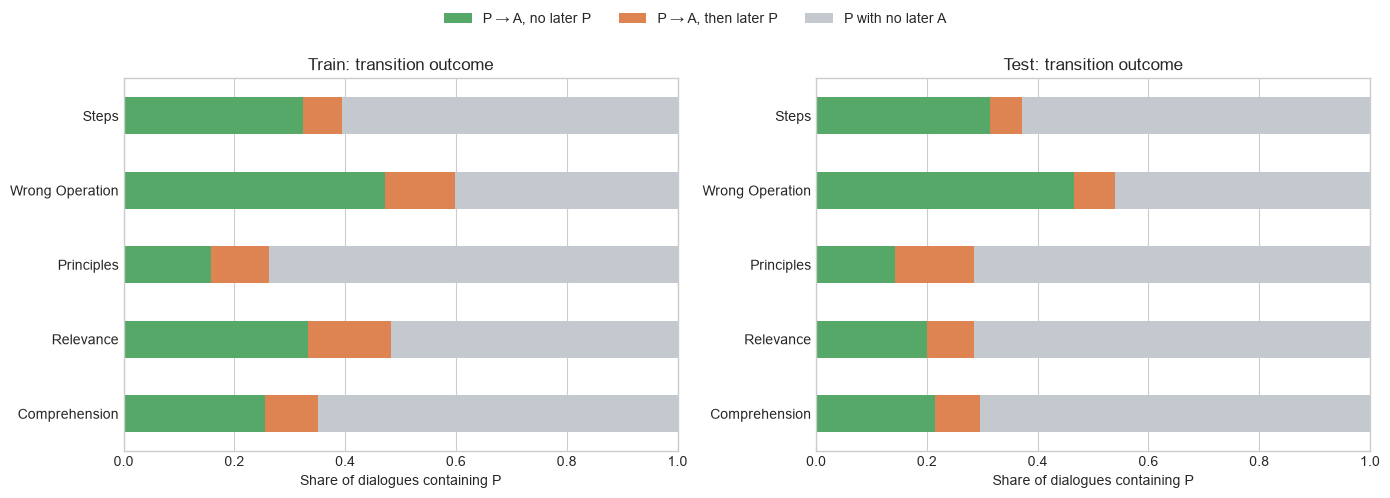

dialogues_with_P  ever_P_to_A  ever_P_to_A_rate  \
split family                                                             
train comprehension                1248          439             0.352   
      relevance                     174           84             0.483   
      principles                     38           10             0.263   
      wrong_operation               766          458             0.598   
      steps                         195           77             0.395   
test  comprehension                 332           98             0.295   
      relevance                      35           10             0.286   
      principles                      7            2             0.286   
      wrong_operation               204          110             0.539   
      steps                          51           19             0.373   

                       P_to_A_then_later_P  last_informative_A_rate  
split family                                                         
train comprehension                    120                    0.275  
      relevance                         26                    0.362  
      principles                         4                    0.211  
      wrong_operation                   96                    0.508  
      steps                             14                    0.333  
test  comprehension                     27                    0.226  
      relevance                          3                    0.200  
      principles                         1                    0.143  
      wrong_operation                   15                    0.475  
      steps                              3                    0.314

In [23]:
def transition_outcome(states):
    first_a = next((i for i, state in enumerate(states) if state == "A" and "P" in states[:i]), None)
    if first_a is None:
        return "P with no later A"
    return "P → A, then later P" if "P" in states[first_a + 1:] else "P → A, no later P"


transition_rows = []
ordered = model_units.sort_values(["split", "dialogue_id", "real_rank"])
for (split, dialogue_id), dialogue in ordered.groupby(["split", "dialogue_id"], sort=False):
    for family in FAMILIES:
        states = dialogue[family].tolist()
        if "P" not in states:
            continue
        outcome = transition_outcome(states)
        informative = [state for state in states if state != "N"]
        transition_rows.append({
            "split": split, "dialogue_id": dialogue_id, "family": family, "outcome": outcome,
            "ever_P_to_A": outcome != "P with no later A",
            "later_P_after_first_A": outcome == "P → A, then later P",
            "last_informative_state": informative[-1],
        })

transitions = pd.DataFrame(transition_rows)
outcomes = ["P → A, no later P", "P → A, then later P", "P with no later A"]
outcome_colors = ["#55A868", "#DD8452", "#C4C8CF"]
summary_rows = []
for split in SPLITS:
    for family in FAMILIES:
        subset = transitions.query("split == @split and family == @family")
        counts = subset["outcome"].value_counts().reindex(outcomes, fill_value=0)
        summary_rows.append({
            "split": split, "family": family, "dialogues_with_P": len(subset),
            "ever_P_to_A": subset["ever_P_to_A"].sum(),
            "ever_P_to_A_rate": subset["ever_P_to_A"].mean(),
            "P_to_A_then_later_P": subset["later_P_after_first_A"].sum(),
            "last_informative_A_rate": subset["last_informative_state"].eq("A").mean(),
            **counts.to_dict(),
        })

transition_summary = pd.DataFrame(summary_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, split in zip(axes, SPLITS):
    table = transition_summary.query("split == @split").set_index("family").reindex(FAMILIES)
    table[outcomes].div(table["dialogues_with_P"], axis=0).plot.barh(stacked=True, ax=ax, color=outcome_colors, legend=False)
    ax.set(title=f"{split.title()}: transition outcome", xlabel="Share of dialogues containing P", ylabel="", xlim=(0, 1))
    ax.set_yticklabels(FAMILY_NAMES)
fig.legend(outcomes, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
display(transition_summary.set_index(["split", "family"])[["dialogues_with_P", "ever_P_to_A", "ever_P_to_A_rate", "P_to_A_then_later_P", "last_informative_A_rate"]].round(3))

## 3.4 Current-turn correctness by annotation state

This is descriptive, not causal. Because annotations were produced after observing the response, current-turn labels must not predict correctness for that same turn.

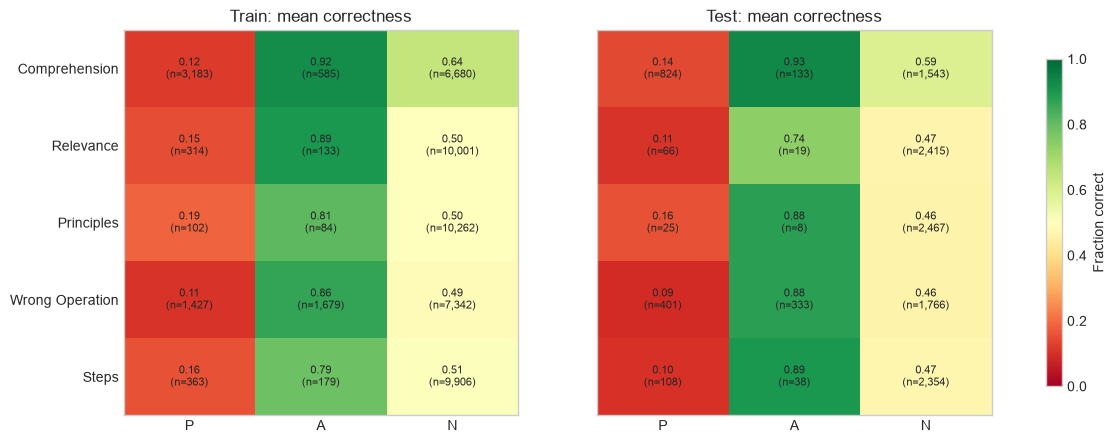

train                 test              
                     P      A      N      P      A      N
comprehension    0.118  0.921  0.642  0.144  0.932  0.587
relevance         0.15  0.895  0.504  0.106  0.737  0.467
principles       0.186   0.81  0.499   0.16  0.875  0.461
wrong_operation  0.106  0.865  0.491  0.092  0.877  0.464
steps            0.157  0.788  0.505  0.102  0.895  0.469

In [24]:
real_units = model_units[model_units["role"].eq("tagged real turn")]
correctness_tables = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, split in zip(axes, SPLITS):
    subset = real_units[real_units["split"].eq(split)]
    means = pd.DataFrame({family: subset.groupby(family)["correct_value"].mean().reindex(STATES) for family in FAMILIES}).T
    counts = pd.DataFrame({family: subset[family].value_counts().reindex(STATES, fill_value=0) for family in FAMILIES}).T
    correctness_tables[split] = means
    image = ax.imshow(means.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax.grid(False)
    ax.set_xticks(range(3), STATES)
    ax.set_yticks(range(len(FAMILIES)), FAMILY_NAMES)
    ax.set_title(f"{split.title()}: mean correctness")
    for row in range(len(FAMILIES)):
        for column in range(len(STATES)):
            ax.text(column, row, f"{means.iat[row, column]:.2f}\n(n={counts.iat[row, column]:,})", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=axes, label="Fraction correct", shrink=0.85)
plt.show()
display(pd.concat(correctness_tables, axis=1).round(3))

# 4. Conclusions and modelling implications

1. The CSVs reproduce the paper-filtered BKT population: 2,050 train dialogues with 10,448 tagged turns, and 515 test dialogues with 2,500 tagged turns.
2. Annotation coverage is complete: every family value is `P`, `A`, or `N`, every `P` has a source, and every dialogue has one stored thread object.
3. The incorrect solution provides the richest initial evidence. Most solutions contain one present misconception family.
4. A later `A` after `P` is transition evidence, but a later return to `P` must remain separate and `N` remains inconclusive.
5. Current-turn annotations are contemporaneous evidence. Use solution and lagged annotations for next-turn prediction to avoid leakage.
6. Keep the paper filters for comparability and handle sparse KCs or families through model design rather than extra filtering.